In [1]:
import numpy as np
import matplotlib.pyplot as plt


Question 3.7

In [2]:
from composite_quadrature_a3 import scientific


In [3]:
from composite_quadrature_a3 import composite_trapezoidal, composite_simpson, f, real_value

#we use the scientific helper code given in order express our values to 3d.p in scientific notation 

print('The composite trapezoidal method for tan(x) on [0,1] with 10 equally spaced intervals gives', scientific(composite_trapezoidal(f, 0, 1, 10), precision=3),'compared to the real value', scientific(real_value(f, 0, 1), precision=3),'and hence error', scientific(abs(composite_trapezoidal(f, 0, 1, 10) -  real_value(f, 0, 1)), precision=3))
print('The composite simpson method for tan(x) on [0,1] with 10 equally spaced intervals gives', scientific(composite_simpson(f, 0, 1, 10), precision=3),'compared to the real value', scientific(real_value(f, 0, 1), precision=3),'and hence error', scientific(abs(composite_simpson(f, 0, 1, 10) -  real_value(f, 0, 1)), precision=3))
                              

The composite trapezoidal method for tan(x) on [0,1] with 10 equally spaced intervals gives 0.618 compared to the real value 0.616 and hence error 2.014E-3
The composite simpson method for tan(x) on [0,1] with 10 equally spaced intervals gives 0.616 compared to the real value 0.616 and hence error 1.865E-6


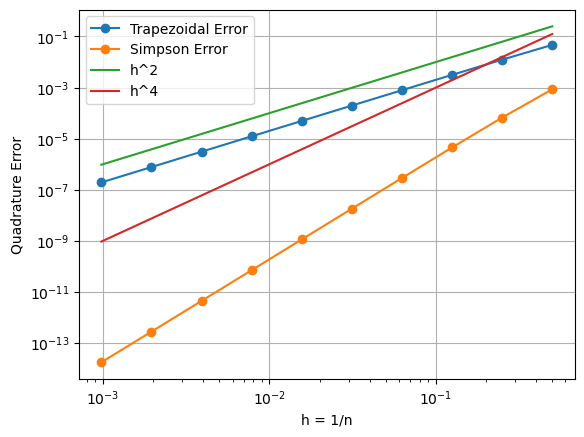

In [4]:
tan_value = real_value(f, 0, 1)
n_values = [2**k for k in range(1,11)] #creating the array of n values 
h_values = [1/n for n in n_values] 
trapezoidal_error = [abs(composite_trapezoidal(f, 0, 1, n) - tan_value) for n in n_values]
simpson_error = [abs(composite_simpson(f, 0, 1, n) - tan_value) for n in n_values]

g_1 = 2
g_2 = 3
h_1_values = [1 / (n**(g_1)) for n in n_values] 

h_2_values = [1 / (n**(g_2)) for n in n_values] 

plt.loglog(h_values, trapezoidal_error,'o-', label='Trapezoidal Error')
plt.loglog(h_values, simpson_error,'o-', label='Simpson Error')
plt.loglog(h_values, h_1_values, label='h^2')
plt.loglog(h_values, h_2_values, label='h^4')
plt.xlabel('h = 1/n')
plt.ylabel('Quadrature Error')
plt.legend()
plt.grid(True)
plt.show()

By comparing gradients, we see here that the scaling of the composite trapezoidal error is approximately h^2 and the composite simpson error approximately h^3

In [5]:

    
import pandas as pd #using pandas to create a table (as is okay by the forum)

#creating arrays of evaluated values using each method for use in our table
trapezoidal_eval = [composite_trapezoidal(f, 0, 1, n) for n in n_values] 
simpson_eval = [composite_simpson(f, 0, 1, n) for n in n_values]

#placing the data into a dictionary in order to create a table
data = {
    "h": h_values, #each "." corresponds to a heading, with its associated values
    "Error I1,n": trapezoidal_error,
    "Eval I1,n": trapezoidal_eval,
    "Error I2,n": simpson_error,
    "Eval I2,n": simpson_eval
}
table = pd.DataFrame(data) #creating the table
print(table)

          h    Error I1,n  Eval I1,n    Error I2,n  Eval I2,n
0  0.500000  4.687671e-02   0.662503  8.540487e-04   0.616481
1  0.250000  1.235971e-02   0.627986  6.688785e-05   0.615693
2  0.125000  3.140094e-03   0.618767  4.507725e-06   0.615631
3  0.062500  7.884043e-04   0.616415  2.877269e-07   0.615627
4  0.031250  1.973169e-04   0.615824  1.808105e-08   0.615626
5  0.015625  4.934278e-05   0.615676  1.131618e-09   0.615626
6  0.007812  1.233654e-05   0.615639  7.075052e-11   0.615626
7  0.003906  3.084189e-06   0.615630  4.422684e-12   0.615626
8  0.001953  7.710506e-07   0.615627  2.770006e-13   0.615626
9  0.000977  1.927628e-07   0.615627  1.743050e-14   0.615626


We see that the most efficient (quickest) way to reach an error of 10^-6 is to use the simpson method, as we achieve an error that small for h = 0.125, compared to h = 0.03906 for the trapezoidal method.

Question 3.8

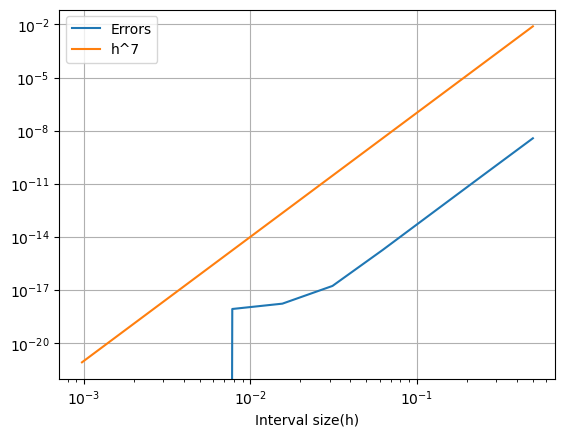

   Interval Size(h)        Errors       EOC
0          0.500000  3.747611e-09       inf
1          0.250000  3.002479e-11  6.963674
2          0.125000  2.360334e-13  6.991019
3          0.062500  1.845746e-15  6.998643
4          0.031250  1.734723e-17  6.733354
5          0.015625  1.734723e-18  3.321928
6          0.007812  8.673617e-19  1.000000
7          0.003906  0.000000e+00       inf
8          0.001953  0.000000e+00       NaN
9          0.000977  0.000000e+00       NaN


C:\Users\oscar\AppData\Local\Temp\ipykernel_5484\2226926437.py:26: RuntimeWarning: divide by zero encountered in log
  eoc = [np.log((errors[k-1])/errors[k])/np.log((h_vals[k-1])/(h_vals[k])) for k in range(10)] #
C:\Users\oscar\AppData\Local\Temp\ipykernel_5484\2226926437.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  eoc = [np.log((errors[k-1])/errors[k])/np.log((h_vals[k-1])/(h_vals[k])) for k in range(10)] #
C:\Users\oscar\AppData\Local\Temp\ipykernel_5484\2226926437.py:26: RuntimeWarning: invalid value encountered in scalar divide
  eoc = [np.log((errors[k-1])/errors[k])/np.log((h_vals[k-1])/(h_vals[k])) for k in range(10)] #


In [6]:
#defining G for 3 nodes using the formula derived in 3.5
from gaussian_quadrature_a3 import G, F, exact_integral
h_vals = [1/2**k for k in range(1,11)] #suitable experiments and spacings
errors = [abs(exact_integral(h) - G(F,0,h)) for h in h_vals] #array of errors

u = 7
h_u_vals = [h**u for h in h_vals] #varying h^u to see possible EOC values

#Plotting on a log-log scale to see comparisons with EOC which is linear on a log-log scale

plt.loglog(h_vals, errors, label='Errors')
plt.loglog(h_vals, h_u_vals, label='h^7')
plt.xlabel('Interval size(h)')
plt.legend()
plt.grid(True)
plt.show()

eoc = [np.log((errors[k-1])/errors[k])/np.log((h_vals[k-1])/(h_vals[k])) for k in range(10)] #

#defining a set of data for a table in order to present the EOC in a clean manner in the same way as used above
data_1 = {
    "Interval Size(h)": h_vals,
    "Errors": errors,
    "EOC": eoc
}
table_1 = pd.DataFrame(data_1)
print(table_1)

We see that the EOC is approaching 7 (in the table), and then for smaller and smaller errors and interval sizes, the truncation automatically done by python for extremely small (O(10^-20)) numbers seems to create issues with the EOC, and gives some unexpected values. This can also be seen by looking at the plot, where the orange line has equation h^7, and has the same scaling for larger h (greater than or equal to 10^-16). We cannot do any better than this precision due to truncation effects we have no control over.

Question 3.9

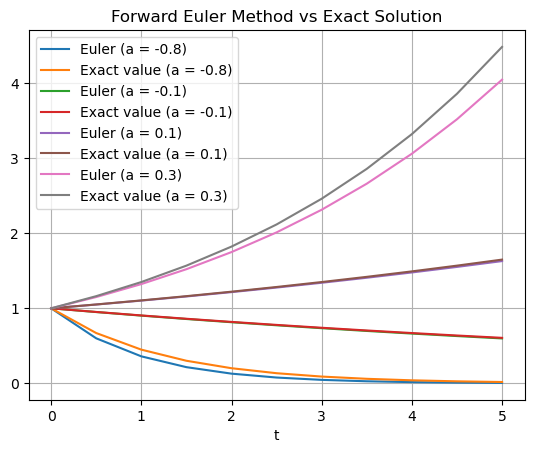

In [7]:
from ode_methods_a3 import exact_solution, forward_euler
t_vals = np.linspace(0, 5, 10+1) #creating the t_values for the plot 

alphas = [-0.8, -0.1, 0.1, 0.3]

#plotting the single figure containing the forward euler and the exact integral for each corresponding value of alpha
for alpha in alphas:
    plt.plot(t_vals, forward_euler(0, 5, 10, alpha), label=f'Euler (a = {alpha})') 
    plt.plot(t_vals, exact_solution(alpha, t_vals), label=f'Exact value (a = {alpha})')
plt.title('Forward Euler Method vs Exact Solution')
plt.xlabel('t')
plt.legend()
plt.grid(True)
plt.show()
    


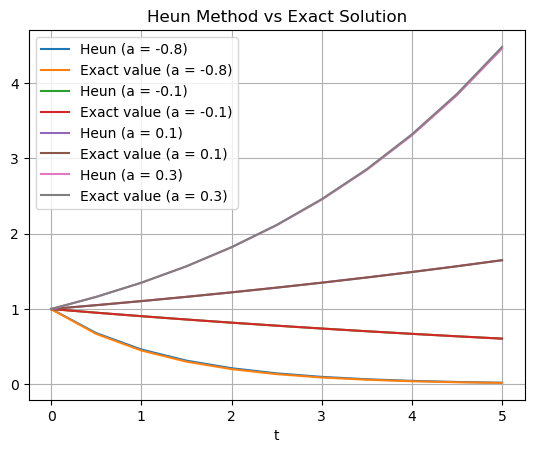

In [8]:
from ode_methods_a3 import heun
for alpha in alphas:  #same set of alphas as before
    plt.plot(t_vals, heun(0, 5, 10, alpha), label=f'Heun (a = {alpha})')
    plt.plot(t_vals, exact_solution(alpha, t_vals), label=f'Exact value (a = {alpha})')
plt.title('Heun Method vs Exact Solution')
plt.xlabel('t')
plt.legend()
plt.grid(True)
plt.show()

Both the Forward Euler and Heun methods pretty much perfectly approximate the exact solution for alpha = -0.1, 0.1, but for the other values, the Heun method is a significantly better approximation. for alpha = -0.8, the Euler method fails to approximate the exact solution effectively between t = 0.5 and t = 3.5, whereas its counterpart does this much more effectively. For alpha = 0.3, the Euler method underestimates the solution more and more as time increases, compared to its counterpart approximating almost perfectly the entire time.